> **归档说明**：本 notebook 记录项目开发过程中的中间实验，保留用于复盘和审计，不作为最终展示入口。部分输入可能依赖本地生成但未上传 GitHub 的过程产物，例如 `outputs/predictions/`、`threshold_metrics` 或 `trial_results`。复现这些历史实验前，请先查看 `reports/notebook_reproducibility_audit.md` 中对应的再生成脚本说明。项目最终展示入口见 `notebooks/final/` 和 `README.md`。
>
> 该实验结果仅作为历史对照，不作为最终模型选择依据。


# Day 11 前缀组结构信号分析

本 notebook 基于 Day 10 字段级分布诊断结果，分析匿名字段前缀是否可以作为结构分组线索。Day 11 不建模、不调参、不做新的结构特征实验，只为 Day 12 的结构特征设计做准备。

## 1. 为什么分析字段前缀

Scania APS 字段已经匿名化，例如 `ag_000`、`ay_009`、`br_000`。前缀不能解释为具体传感器或部件，只能作为匿名结构分组线索。

如果某些前缀组内部字段具有相似的缺失、零值、偏态或 pos/neg 差异结构，后续 Day 12 可以考虑构造前缀组级统计特征，例如组内缺失计数、零值计数、分位数聚合等。official test 中的 drift 只用于观察泛化风险，不能用于反向选择策略。

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

import pandas as pd

from scania_aps.config import get_config
from scania_aps.analysis.prefix_group_analysis import (
    add_prefix_column,
    build_prefix_feature_members,
    build_prefix_group_signal_ranking,
    build_prefix_group_summary,
)

cfg = get_config(PROJECT_ROOT / "config" / "config.yaml")

## 2. 读取 Day 10 输出表

In [2]:
distribution_summary = pd.read_csv(cfg.metrics_dir / "day10_feature_distribution_summary.csv")
missing_zero_summary = pd.read_csv(cfg.metrics_dir / "day10_missing_zero_summary.csv")
pos_neg_diff = pd.read_csv(cfg.metrics_dir / "day10_pos_neg_distribution_diff.csv")
drift_summary = pd.read_csv(cfg.metrics_dir / "day10_train_valid_test_drift_summary.csv")

distribution_summary.shape, missing_zero_summary.shape, pos_neg_diff.shape, drift_summary.shape

((510, 22), (510, 6), (170, 17), (170, 16))

## 3. 提取字段前缀并生成前缀组统计

In [3]:
distribution_with_prefix = add_prefix_column(distribution_summary)
prefix_group_summary = build_prefix_group_summary(
    distribution_summary,
    missing_zero_summary,
    pos_neg_diff,
    drift_summary,
)
prefix_signal_ranking = build_prefix_group_signal_ranking(prefix_group_summary)
prefix_feature_members = build_prefix_feature_members(prefix_group_summary)

prefix_group_summary.shape, prefix_signal_ranking.shape, prefix_feature_members.shape

((107, 23), (107, 10), (170, 3))

## 4. 前缀组数量和字段数量分布

In [4]:
display(prefix_group_summary["feature_count"].value_counts().sort_index().rename("prefix_group_count"))
display(prefix_group_summary.query("feature_count > 1")[
    ["prefix", "feature_count", "feature_names", "avg_missing_rate", "avg_zero_rate", "avg_abs_skew"]
].sort_values(["feature_count", "prefix"], ascending=[False, True]))

feature_count
1     100
10      7
Name: prefix_group_count, dtype: int64

,prefix,feature_count,feature_names,avg_missing_rate,avg_zero_rate,avg_abs_skew
0,ag,10,"ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_0...",0.010958,0.511665,47.638014
1,ay,10,"ay_000,ay_001,ay_002,ay_003,ay_004,ay_005,ay_0...",0.010937,0.680919,53.456561
2,az,10,"az_000,az_001,az_002,az_003,az_004,az_005,az_0...",0.010937,0.288060,59.004227
3,ba,10,"ba_000,ba_001,ba_002,ba_003,ba_004,ba_005,ba_0...",0.011250,0.135825,18.760063
4,cn,10,"cn_000,cn_001,cn_002,cn_003,cn_004,cn_005,cn_0...",0.011229,0.327723,30.607857
5,cs,10,"cs_000,cs_001,cs_002,cs_003,cs_004,cs_005,cs_0...",0.010917,0.139450,60.849442
6,ee,10,"ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_0...",0.010937,0.118619,15.599665


## 5. 前缀组平均缺失率分析

In [5]:
prefix_group_summary.sort_values("avg_missing_rate", ascending=False)[
    ["prefix", "feature_count", "feature_names", "avg_missing_rate", "max_missing_rate", "high_missing_feature_count_50", "high_missing_feature_count_80"]
].head(20)

,prefix,feature_count,feature_names,avg_missing_rate,max_missing_rate,high_missing_feature_count_50,high_missing_feature_count_80
45,br,1,br_000,0.821625,0.821625,1,1
44,bq,1,bq_000,0.813021,0.813021,1,1
43,bp,1,bp_000,0.796750,0.796750,1,0
42,bo,1,bo_000,0.773875,0.773875,1,0
69,cr,1,cr_000,0.771479,0.771479,1,0
8,ab,1,ab_000,0.771479,0.771479,1,0
41,bn,1,bn_000,0.735437,0.735437,1,0
40,bm,1,bm_000,0.661375,0.661375,1,0
39,bl,1,bl_000,0.455104,0.455104,0,0
38,bk,1,bk_000,0.384271,0.384271,0,0


## 6. 前缀组平均零值率分析

In [6]:
prefix_group_summary.sort_values("avg_zero_rate", ascending=False)[
    ["prefix", "feature_count", "feature_names", "avg_zero_rate", "max_zero_rate", "high_zero_feature_count_50", "high_zero_feature_count_90"]
].head(20)

,prefix,feature_count,feature_names,avg_zero_rate,max_zero_rate,high_zero_feature_count_50,high_zero_feature_count_90
24,as,1,as_000,0.988938,0.988938,1,1
26,au,1,au_000,0.988250,0.988250,1,1
105,ef,1,ef_000,0.950521,0.950521,1,1
100,dz,1,dz_000,0.949917,0.949917,1,1
106,eg,1,eg_000,0.946812,0.946812,1,1
101,ea,1,ea_000,0.942417,0.942417,1,1
85,dj,1,dj_000,0.930167,0.930167,1,1
87,dl,1,dl_000,0.929521,0.929521,1,1
88,dm,1,dm_000,0.928917,0.928917,1,1
86,dk,1,dk_000,0.928125,0.928125,1,1


## 7. 前缀组 pos/neg 缺失率和零值率差异

In [7]:
display(prefix_group_summary.sort_values("avg_abs_pos_neg_missing_diff", ascending=False)[
    ["prefix", "feature_count", "avg_abs_pos_neg_missing_diff", "max_abs_pos_neg_missing_diff", "feature_names"]
].head(20))

display(prefix_group_summary.sort_values("avg_abs_pos_neg_zero_diff", ascending=False)[
    ["prefix", "feature_count", "avg_abs_pos_neg_zero_diff", "max_abs_pos_neg_zero_diff", "feature_names"]
].head(20))

,prefix,feature_count,avg_abs_pos_neg_missing_diff,max_abs_pos_neg_missing_diff,feature_names
45,br,1,0.741483,0.741483,br_000
44,bq,1,0.736547,0.736547,bq_000
43,bp,1,0.725085,0.725085,bp_000
42,bo,1,0.706907,0.706907,bo_000
41,bn,1,0.670360,0.670360,bn_000
40,bm,1,0.597585,0.597585,bm_000
84,di,1,0.458411,0.458411,di_000
87,dl,1,0.458390,0.458390,dl_000
86,dk,1,0.458390,0.458390,dk_000
83,dh,1,0.458390,0.458390,dh_000


,prefix,feature_count,avg_abs_pos_neg_zero_diff,max_abs_pos_neg_zero_diff,feature_names
14,ai,1,0.649470,0.649470,ai_000
17,al,1,0.558729,0.558729,al_000
18,am,1,0.556822,0.556822,am_0
23,ar,1,0.528369,0.528369,ar_000
81,df,1,0.499068,0.499068,df_000
82,dg,1,0.494195,0.494195,dg_000
16,ak,1,0.482331,0.482331,ak_000
83,dh,1,0.471970,0.471970,dh_000
86,dk,1,0.458263,0.458263,dk_000
85,dj,1,0.457797,0.457797,dj_000


## 8. 前缀组偏态 / 长尾概览

In [8]:
prefix_group_summary.sort_values("avg_abs_skew", ascending=False)[
    ["prefix", "feature_count", "avg_abs_skew", "max_abs_skew", "feature_names"]
].head(20)

,prefix,feature_count,avg_abs_skew,max_abs_skew,feature_names
58,cf,1,190.078931,190.078931,cf_000
66,co,1,190.078929,190.078929,co_000
10,ad,1,190.078929,190.078929,ad_000
83,dh,1,181.733007,181.733007,dh_000
85,dj,1,140.829031,140.829031,dj_000
26,au,1,114.227247,114.227247,au_000
24,as,1,106.459652,106.459652,as_000
70,ct,1,104.870652,104.870652,ct_000
16,ak,1,104.264165,104.264165,ak_000
100,dz,1,103.583632,103.583632,dz_000


## 9. 前缀组 train/test drift 风险

In [9]:
prefix_signal_ranking.sort_values("drift_risk_score", ascending=False).head(20)

,prefix,feature_count,signal_score,drift_risk_score,avg_missing_rate,avg_zero_rate,avg_abs_pos_neg_missing_diff,avg_abs_pos_neg_zero_diff,avg_abs_skew,recommendation
34,cl,1,0.411278,0.741069,0.158750,0.614542,0.076271,0.366907,19.385946,单字段前缀，不适合作为前缀聚合主线
73,du,1,0.202484,0.721712,0.045250,0.054208,0.332797,0.020805,8.160594,单字段前缀，不适合作为前缀聚合主线
78,ec,1,0.183026,0.716959,0.170396,0.021021,0.145784,0.023114,9.872357,单字段前缀，不适合作为前缀聚合主线
21,dq,1,0.484219,0.707479,0.045229,0.739354,0.332818,0.314597,35.562477,单字段前缀，不适合作为前缀聚合主线
79,ed,1,0.177410,0.684818,0.158750,0.023583,0.076271,0.086610,8.761734,单字段前缀，不适合作为前缀聚合主线
71,cv,1,0.226255,0.679547,0.229604,0.016938,0.305487,0.015826,7.103781,单字段前缀，不适合作为前缀聚合主线
69,dv,1,0.228340,0.674997,0.045250,0.054167,0.332797,0.020763,17.075308,单字段前缀，不适合作为前缀聚合主线
36,eb,1,0.408855,0.657895,0.066750,0.356917,0.458390,0.309576,13.360201,单字段前缀，不适合作为前缀聚合主线
70,dc,1,0.227240,0.652929,0.229604,0.016938,0.305487,0.015826,7.316036,单字段前缀，不适合作为前缀聚合主线
31,dx,1,0.414934,0.644976,0.045208,0.658396,0.332839,0.284386,10.631172,单字段前缀，不适合作为前缀聚合主线


## 10. Prefix signal ranking

In [10]:
prefix_signal_ranking.head(30)

,prefix,feature_count,signal_score,drift_risk_score,avg_missing_rate,avg_zero_rate,avg_abs_pos_neg_missing_diff,avg_abs_pos_neg_zero_diff,avg_abs_skew,recommendation
0,dj,1,0.657630,0.157895,0.066750,0.930167,0.458390,0.457797,140.829031,单字段前缀，不适合作为前缀聚合主线
1,ak,1,0.653396,0.145749,0.073375,0.920542,0.458008,0.482331,104.264165,单字段前缀，不适合作为前缀聚合主线
2,df,1,0.651957,0.268234,0.066771,0.915750,0.458369,0.499068,93.484000,单字段前缀，不适合作为前缀聚合主线
3,dh,1,0.648677,0.355036,0.066750,0.816604,0.458390,0.471970,181.733007,单字段前缀，不适合作为前缀聚合主线
4,dg,1,0.643238,0.400468,0.066771,0.907208,0.458369,0.494195,80.795170,单字段前缀，不适合作为前缀聚合主线
5,dm,1,0.618953,0.155870,0.066771,0.928917,0.458369,0.453983,52.320693,单字段前缀，不适合作为前缀聚合主线
6,dl,1,0.617802,0.157895,0.066750,0.929521,0.458390,0.454597,50.310472,单字段前缀，不适合作为前缀聚合主线
7,dk,1,0.614839,0.157895,0.066750,0.928125,0.458390,0.458263,45.424984,单字段前缀，不适合作为前缀聚合主线
8,ch,1,0.607130,0.147773,0.247292,0.752542,0.404449,0.405551,67.183517,单字段前缀，不适合作为前缀聚合主线
9,ar,1,0.577934,0.246964,0.045208,0.915813,0.332839,0.528369,28.788420,单字段前缀，不适合作为前缀聚合主线


## 11. 适合进入 Day 12 的前缀组候选

从结果看，107 个前缀组里有 100 个是单字段前缀，真正适合做“前缀组聚合”的多字段前缀只有 7 个：`ag`、`ay`、`az`、`ba`、`cn`、`cs`、`ee`。

- `ag`：组内平均零值率较高，pos/neg 零值率差异相对明显，可作为 zero-count / zero-rate 聚合候选。
- `ay`：组内平均零值率最高，且偏态明显，可作为零值结构和长尾结构候选。
- `cn`：组内零值率和 pos/neg 零值差异较明显，可作为结构聚合备选。
- `az`、`cs`：组内偏态较高，可作为长尾结构观察候选。
- `ba`、`ee`：组内信号较弱，可作为低优先级备选。

单字段前缀如 `br`、`bq`、`bp`、`bo`、`dj`、`ak` 等虽然可能有强信号，但它们不适合作为前缀聚合主线，更适合在字段级缺失指示或单字段稳健处理时观察。

## 12. 图表展示

图表由 `scripts/09_prefix_group_analysis.py` 生成并保存到 `outputs/figures/`。

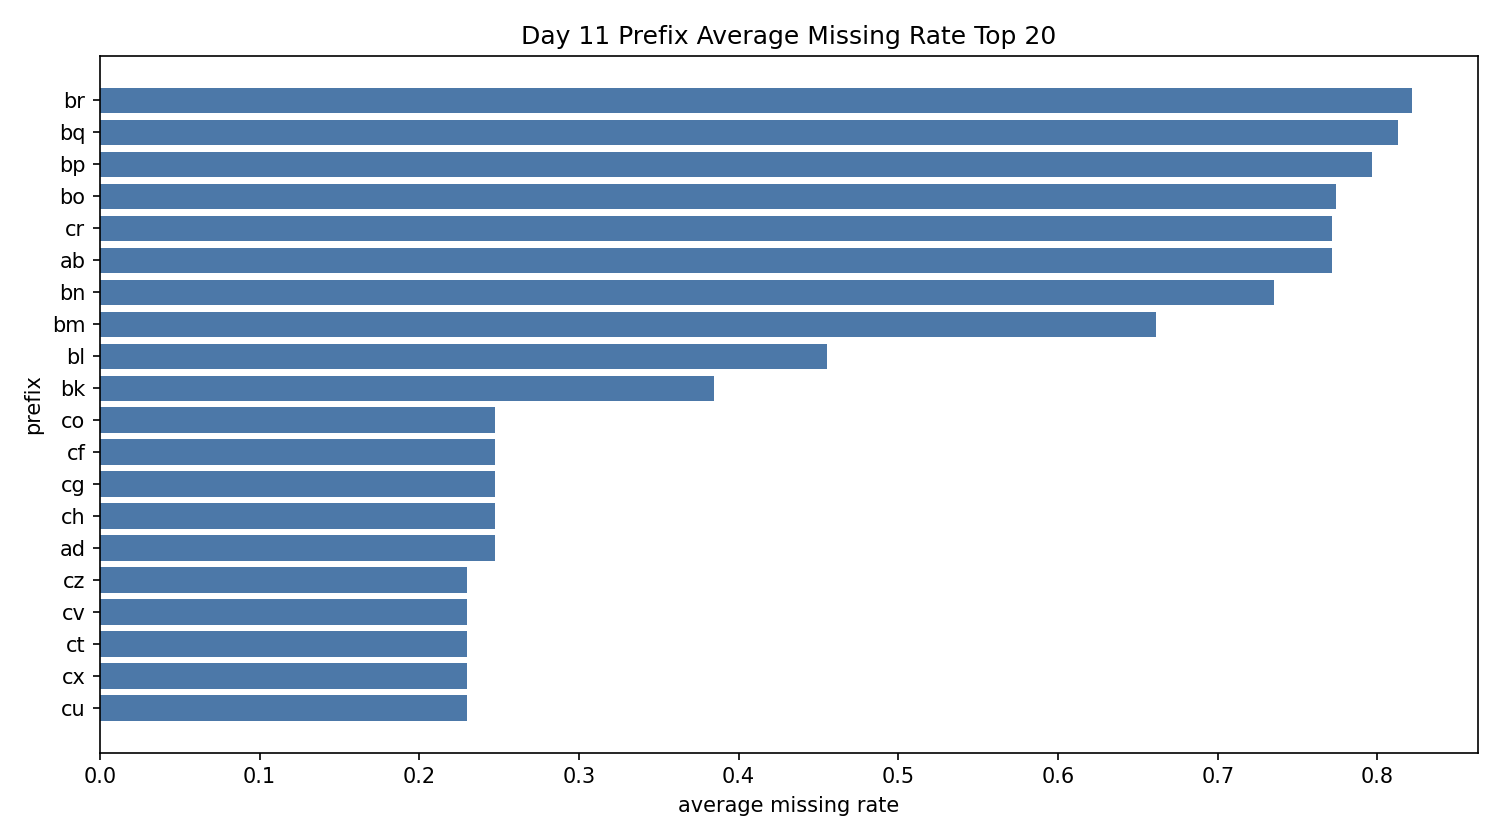

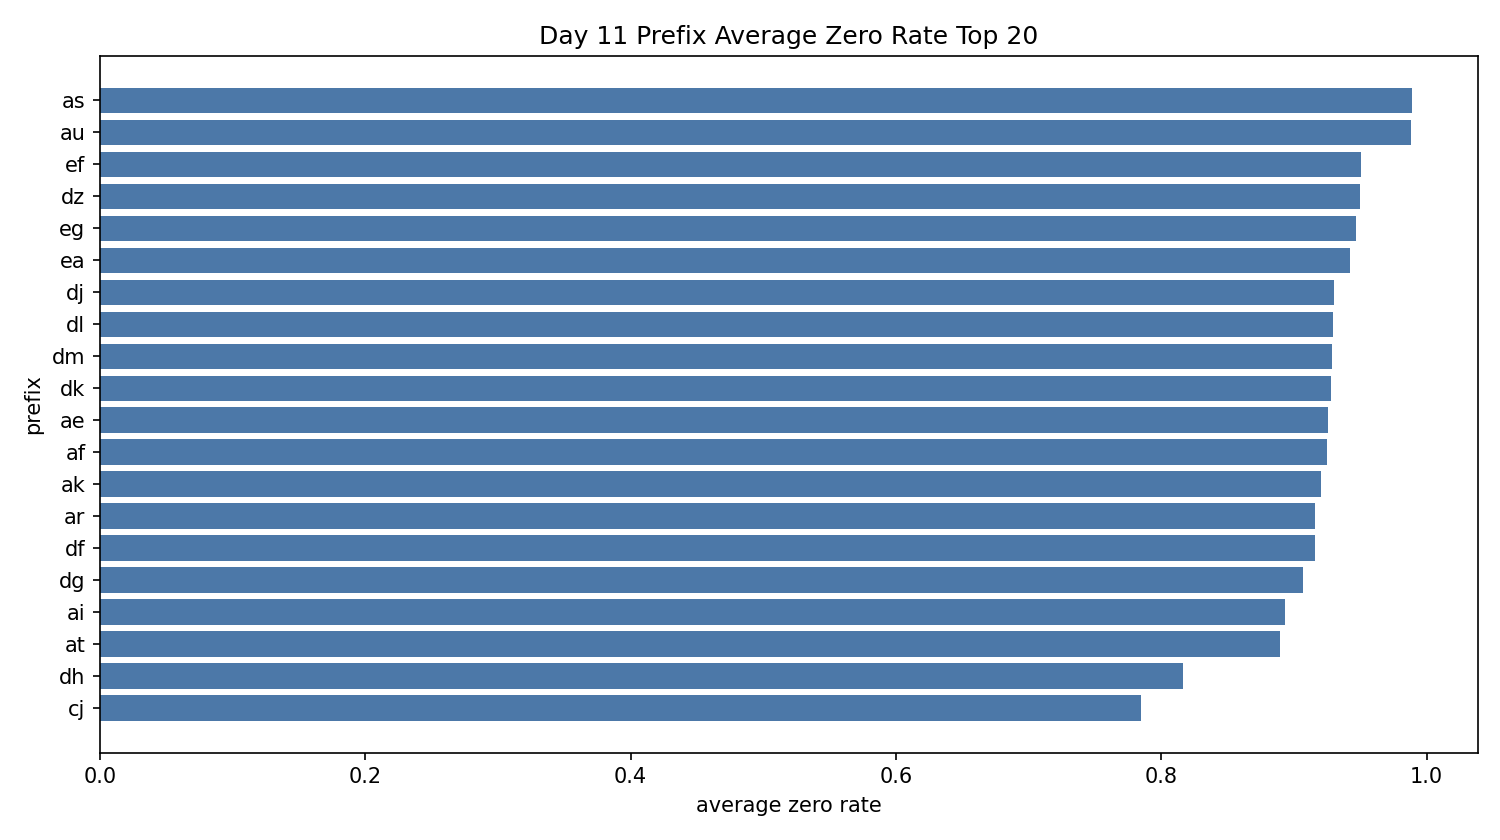

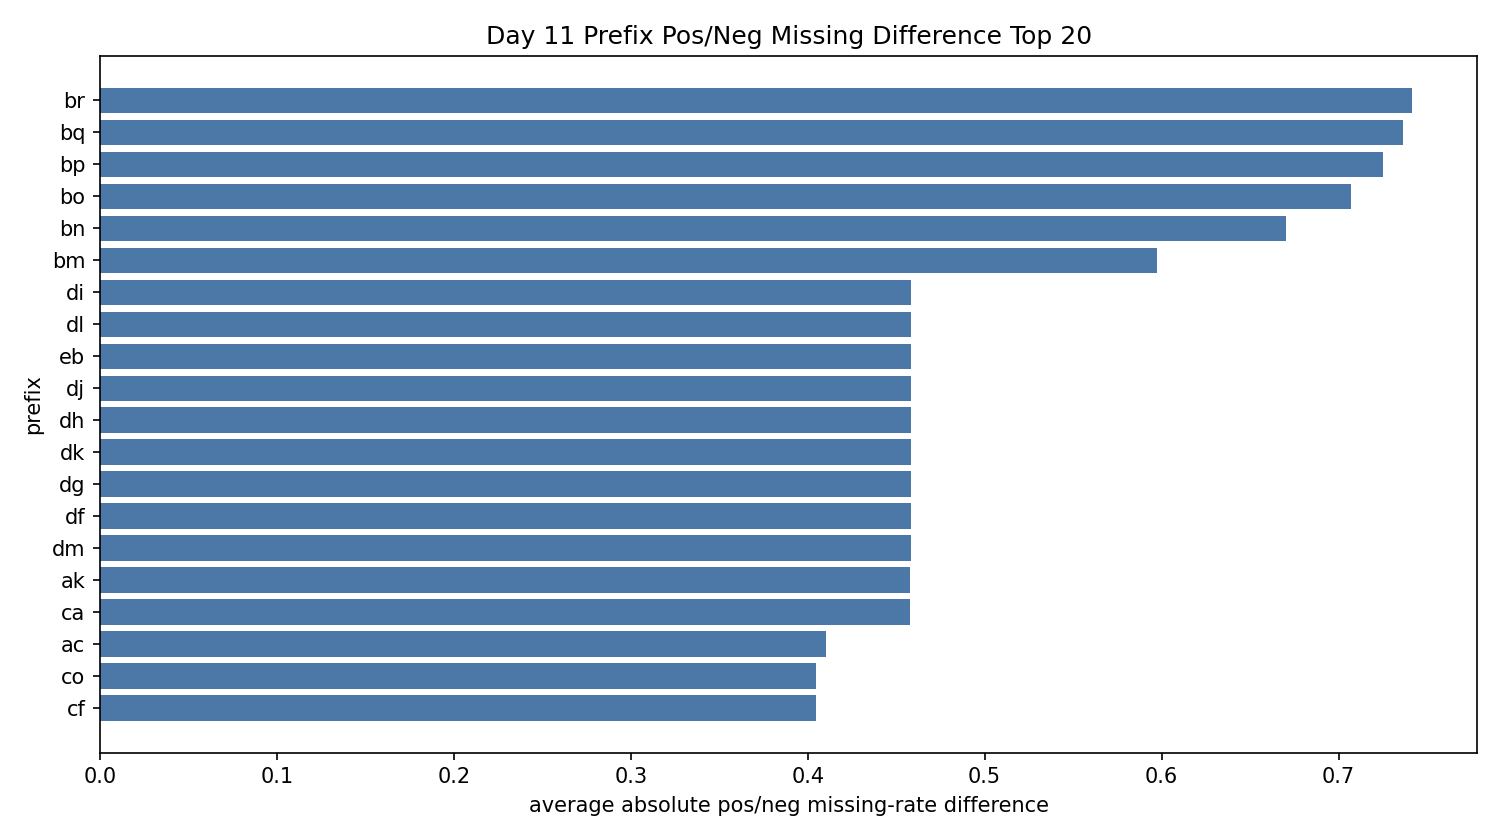

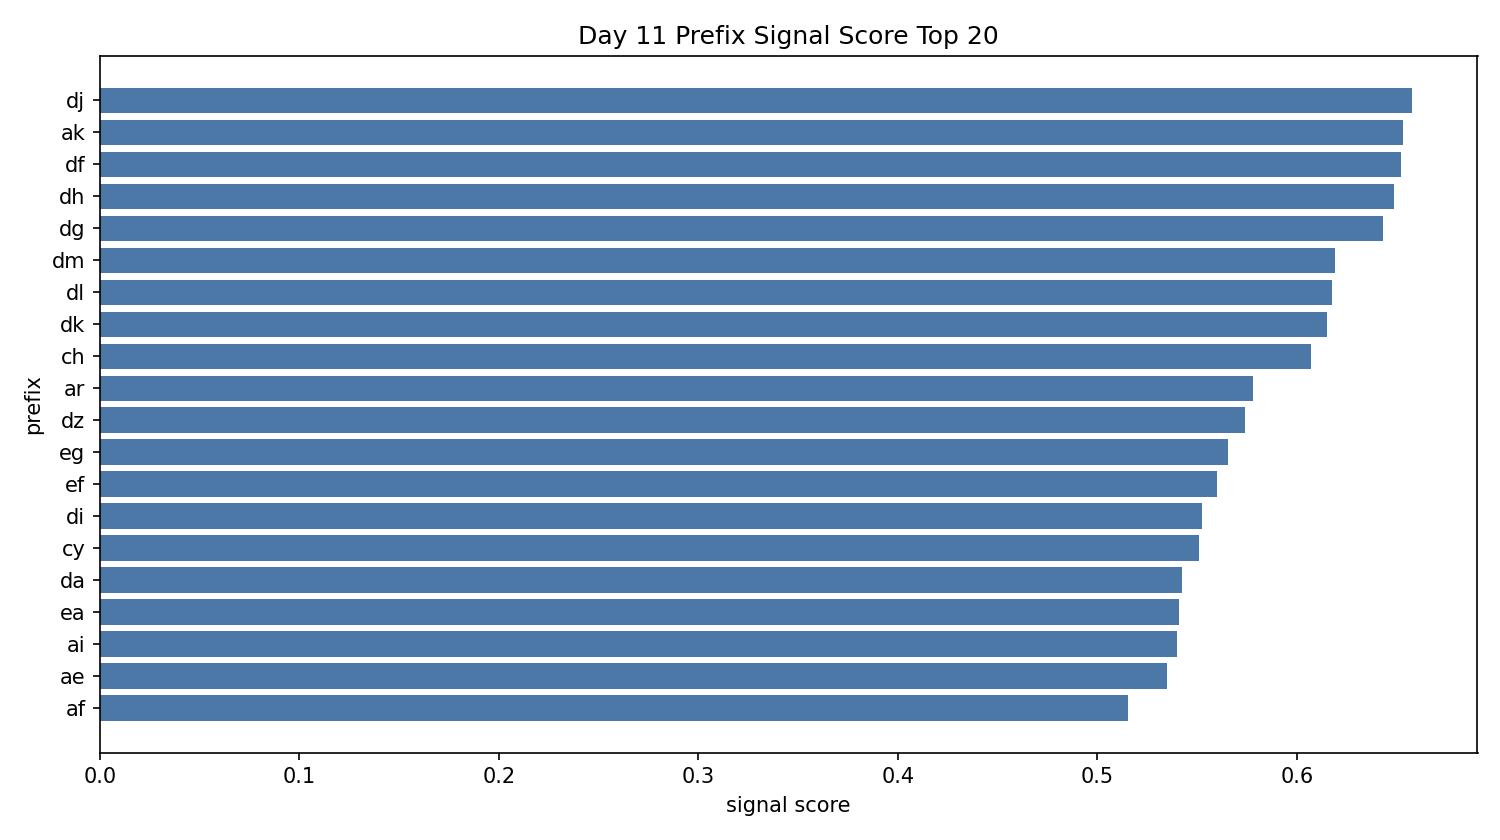

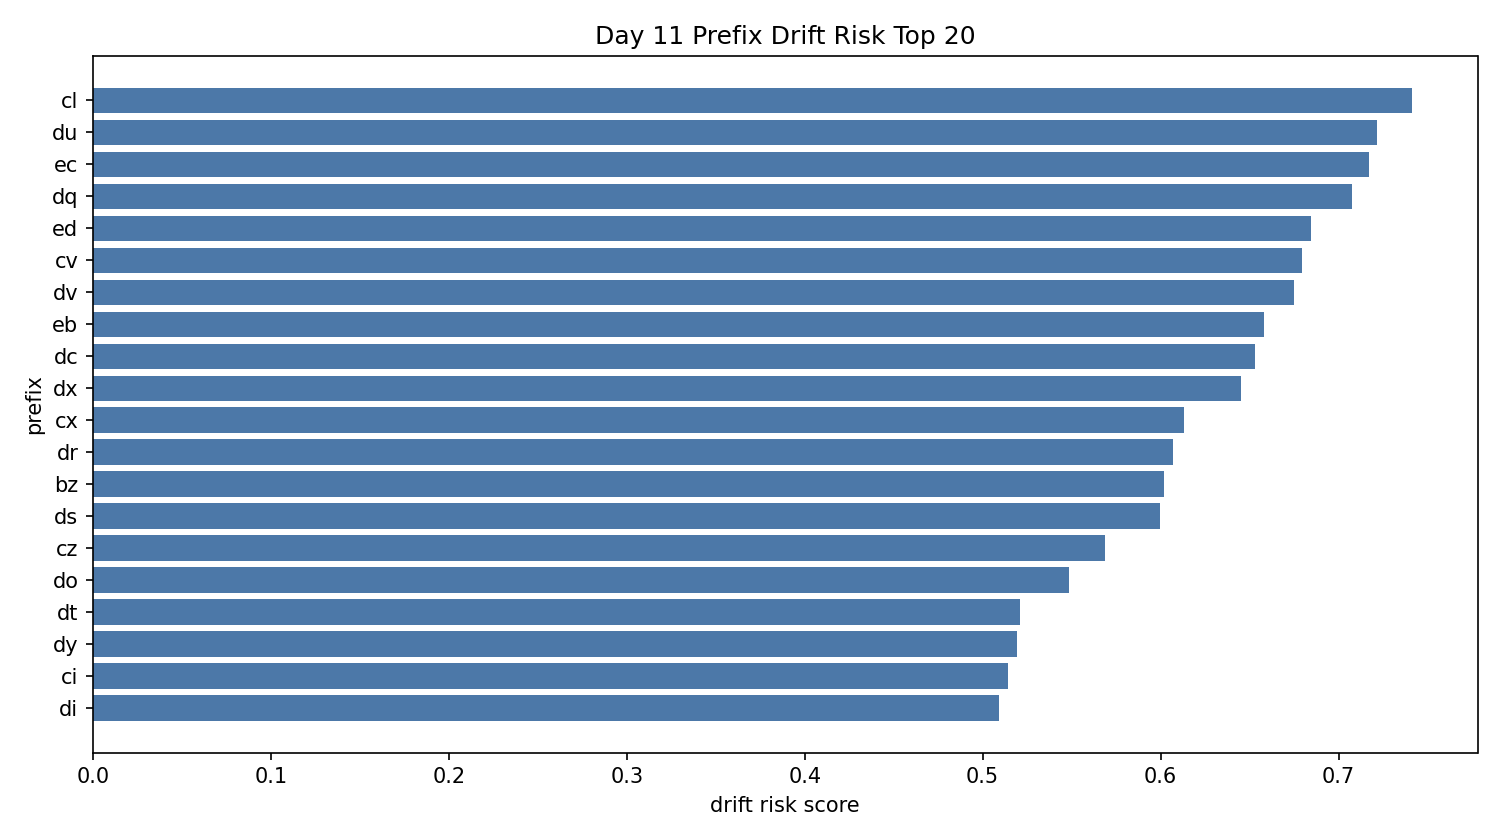

In [11]:
from IPython.display import Image, display

for figure_name in [
    "day11_prefix_avg_missing_rate_top20.png",
    "day11_prefix_avg_zero_rate_top20.png",
    "day11_prefix_pos_neg_missing_diff_top20.png",
    "day11_prefix_signal_score_top20.png",
    "day11_prefix_drift_risk_top20.png",
]:
    path = cfg.figures_dir / figure_name
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"图表尚未生成：{path}")

## 13. Day 11 中文小结

字段前缀可以作为匿名结构分组线索，但不能被解释为真实物理含义。当前数据中大部分前缀是单字段，只有 `ag`、`ay`、`az`、`ba`、`cn`、`cs`、`ee` 是 10 字段组，真正适合 Day 12 设计前缀组聚合特征。

Day 12 可以优先围绕 `ag`、`ay`、`cn` 设计组内缺失计数、零值计数、零值率和分位数统计；`az`、`cs` 可作为长尾结构候选；`ba`、`ee` 保留为低优先级备选。所有结构特征仍必须在 train_inner / valid 流程中评估，official test 只用于最终评估，不能反向决定策略。